# Predicting Building Energy Efficiency

**Goal:** Predict the **heating load** and **cooling load** of a building from its shape and glazing (window) features.

**Dataset:** Energy Efficiency dataset (ENB2012) - 768 simulated buildings, 8 input features, 2 targets.

| Original name | Meaning |
|---|---|
| X1 | Relative compactness |
| X2 | Surface area |
| X3 | Wall area |
| X4 | Roof area |
| X5 | Overall height |
| X6 | Orientation |
| X7 | Glazing area |
| X8 | Glazing area distribution |
| Y1 | Heating load |
| Y2 | Cooling load |

**Steps:**
1. Load and clean the data
2. Explore the data (EDA)
3. Train / test split
4. Linear Regression and Random Forest
5. Cross-validation
6. Feature selection experiment
7. Ridge and Lasso
8. Gradient Boosting and tuning
9. Final comparison, saving the model and conclusions

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/Shanmukhi1920/Energy-Efficiency-Prediction/main/data/ENB2012_data.csv')

In [2]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
df.columns = ['relative_compactness', 'surface_area', 'wall_area', 'roof_area',
              'overall_height', 'orientation', 'glazing_area',
              'glazing_area_distribution', 'heating_load', 'cooling_load']
df.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 2. Data checks

In [4]:
print('Shape :', df.shape)
print('Duplicate rows :', df.duplicated().sum())
print()
print('Missing values')
print(df.isnull().sum())

Shape : (768, 10)
Duplicate rows : 0

Missing values
relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
heating_load                 0
cooling_load                 0
dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
 8   heating_load               768 non-null    float64
 9   cooling_load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [6]:
df.describe()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load,cooling_load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


**Observation:** There are no missing values and no duplicate rows, so no cleaning is needed.
`glazing_area`, `glazing_area_distribution`, `orientation` and `overall_height` only take a few distinct values, so they behave like categories.

In [7]:
print(df['glazing_area'].value_counts())
print()
print(df['glazing_area_distribution'].value_counts())
print()
print(df['overall_height'].value_counts())
print()
print(df['orientation'].value_counts())

glazing_area
0.10    240
0.25    240
0.40    240
0.00     48
Name: count, dtype: int64

glazing_area_distribution
1    144
2    144
3    144
4    144
5    144
0     48
Name: count, dtype: int64

overall_height
7.0    384
3.5    384
Name: count, dtype: int64

orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64


## 3. Exploratory Data Analysis

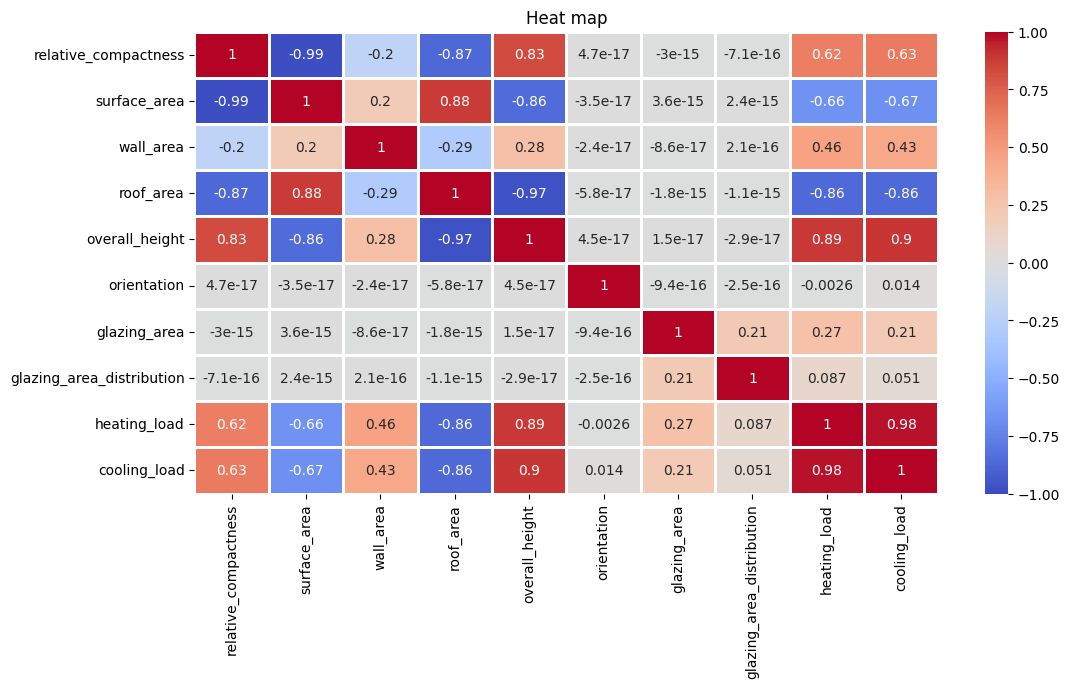

In [8]:
plt.figure(figsize=(12,6))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidth=1)
plt.title('Heat map')
plt.show()

**Observation:** Several input features are strongly related to each other
(for example `relative_compactness` and `surface_area` are almost perfectly negatively correlated).
This is called **multicollinearity** and it makes linear model coefficients hard to interpret.
Also, `heating_load` and `cooling_load` are strongly correlated with each other.

In [9]:
# correlation of every feature with the two targets
target_corr = corr_matrix[['heating_load', 'cooling_load']].drop(['heating_load', 'cooling_load'])
print(target_corr.sort_values('heating_load', ascending=False).round(3))

                           heating_load  cooling_load
overall_height                    0.889         0.896
relative_compactness              0.622         0.634
wall_area                         0.456         0.427
glazing_area                      0.270         0.208
glazing_area_distribution         0.087         0.051
orientation                      -0.003         0.014
surface_area                     -0.658        -0.673
roof_area                        -0.862        -0.863


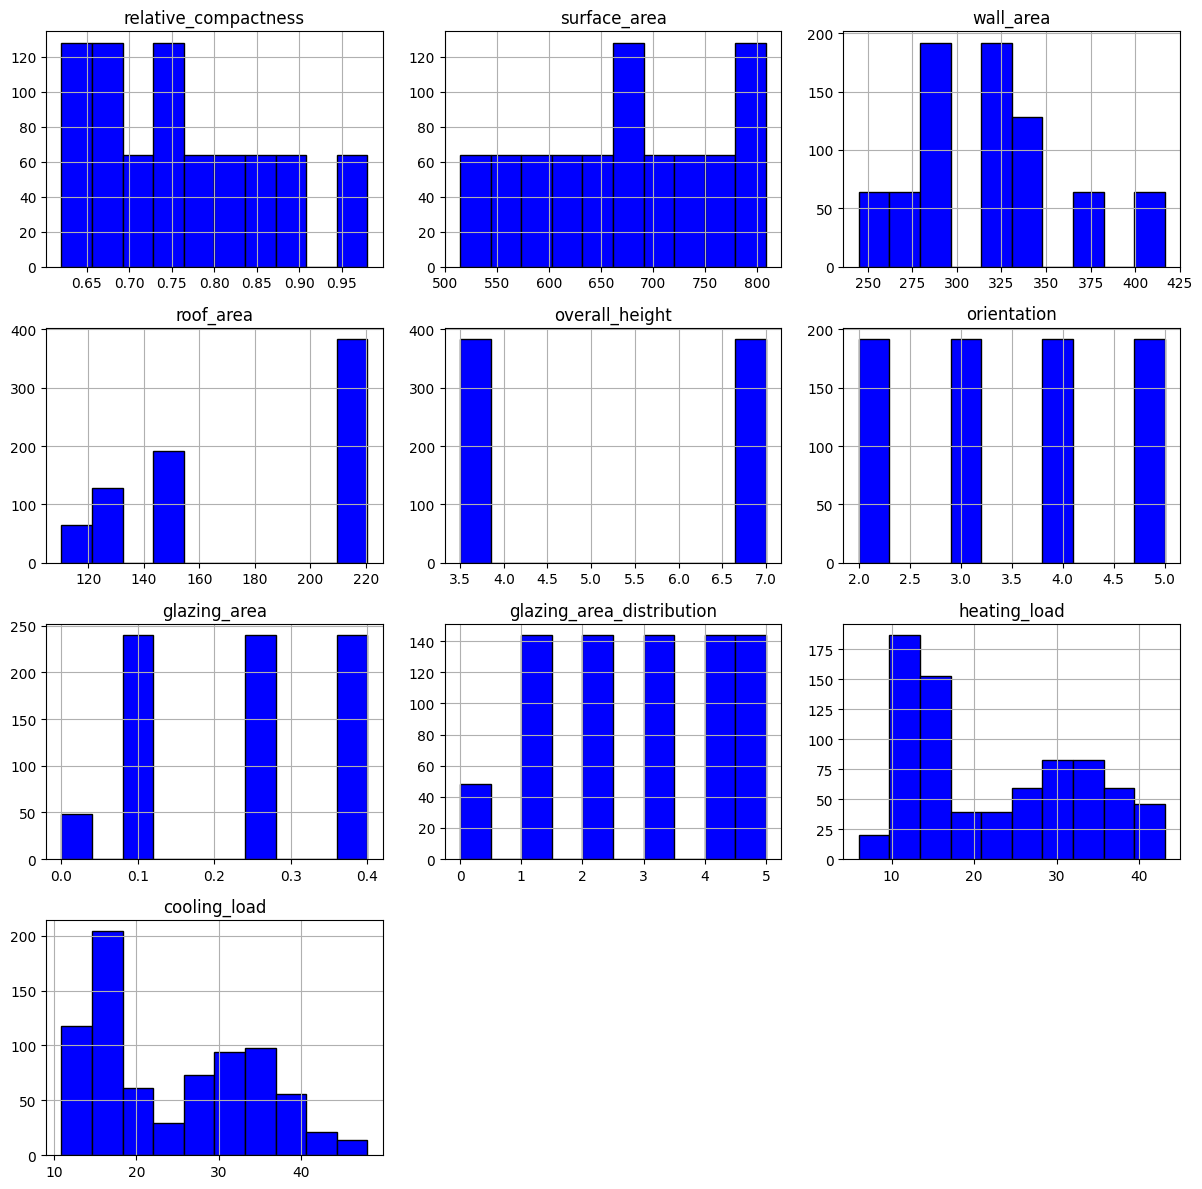

In [10]:
df.hist(figsize=(12,12), color='blue', edgecolor='black')
plt.tight_layout()
plt.show()

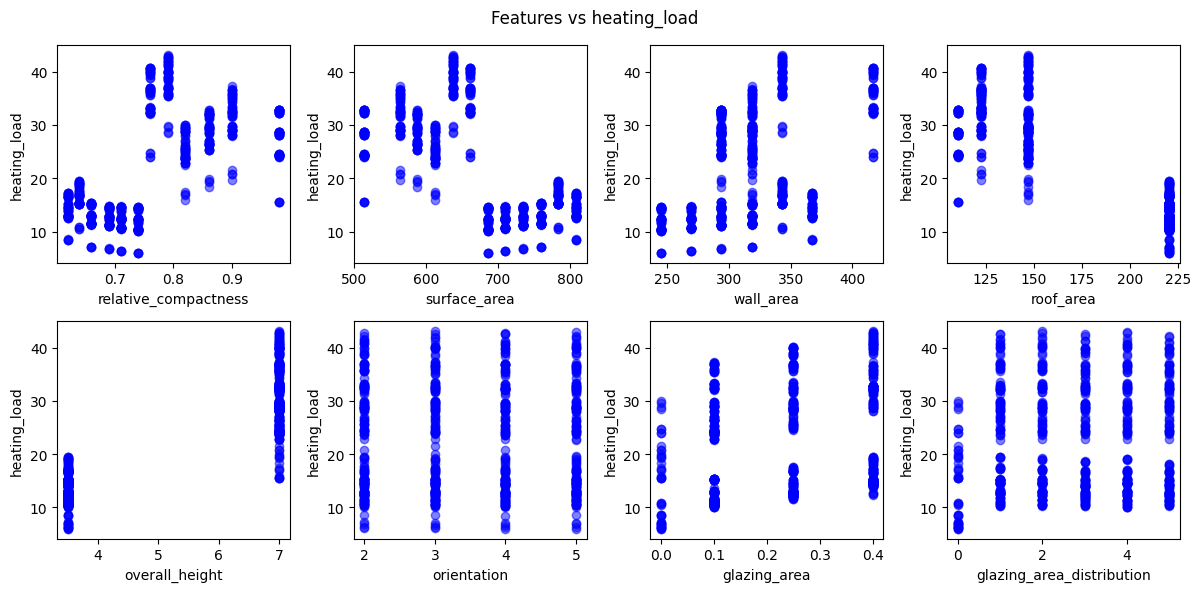

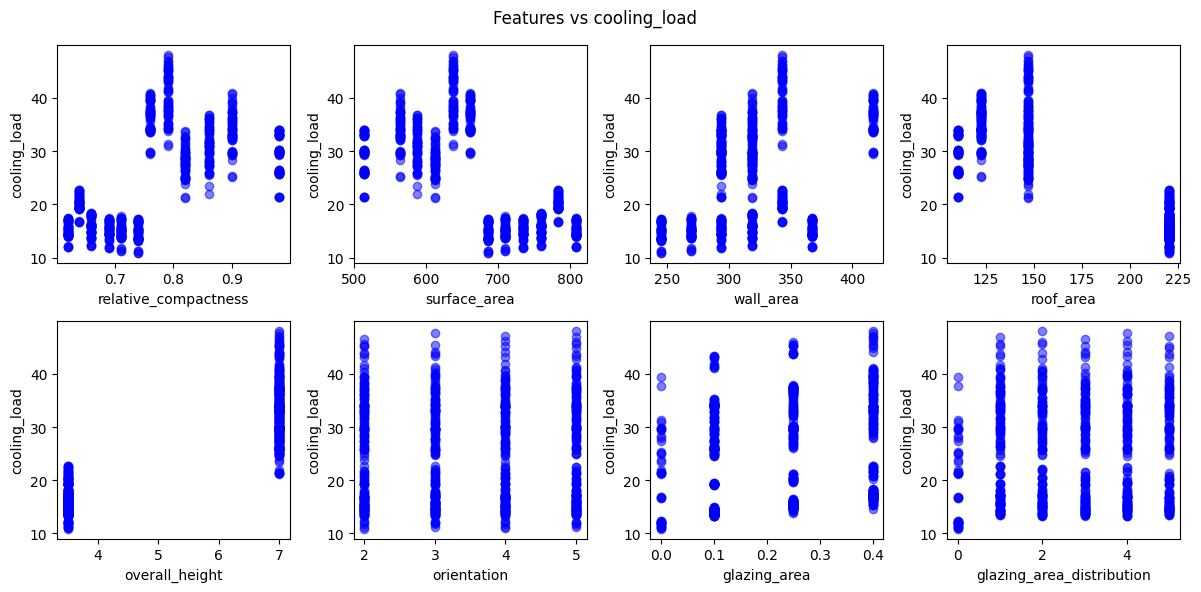

In [11]:
features = df[df.columns.drop(['heating_load', 'cooling_load'])]

for target_name in ['heating_load', 'cooling_load']:
    fig, axes = plt.subplots(2, 4, figsize=(12,6))
    axes = axes.flatten()

    for idx, col in enumerate(features.columns):
        axes[idx].scatter(features[col], df[target_name], color='Blue', alpha=0.5)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(target_name)

    plt.suptitle(f'Features vs {target_name}')
    plt.tight_layout()
    plt.show()

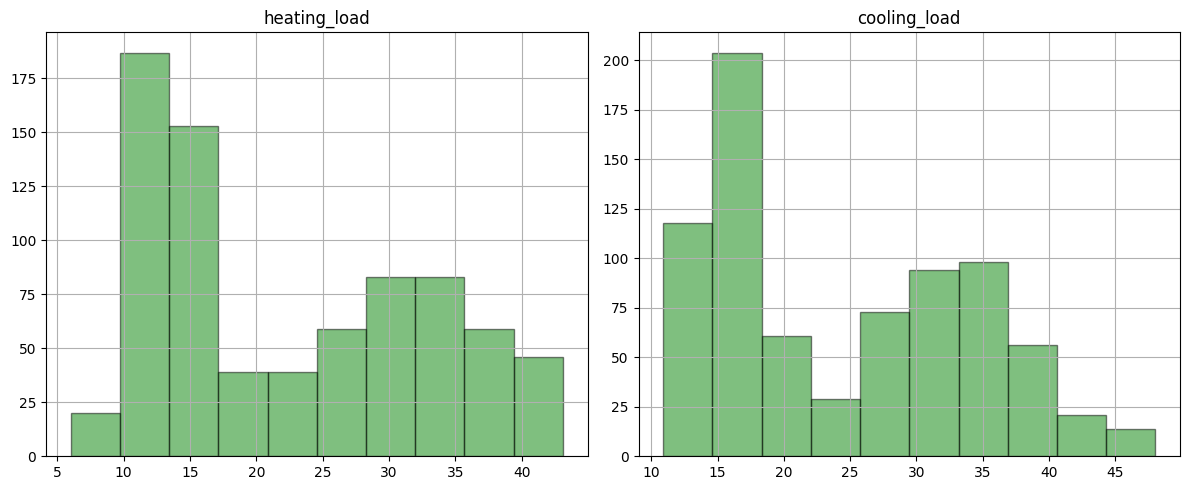

In [12]:
df[['heating_load', 'cooling_load']].hist(figsize=(12,5), color='green', edgecolor='black', alpha=0.5)
plt.tight_layout()
plt.show()

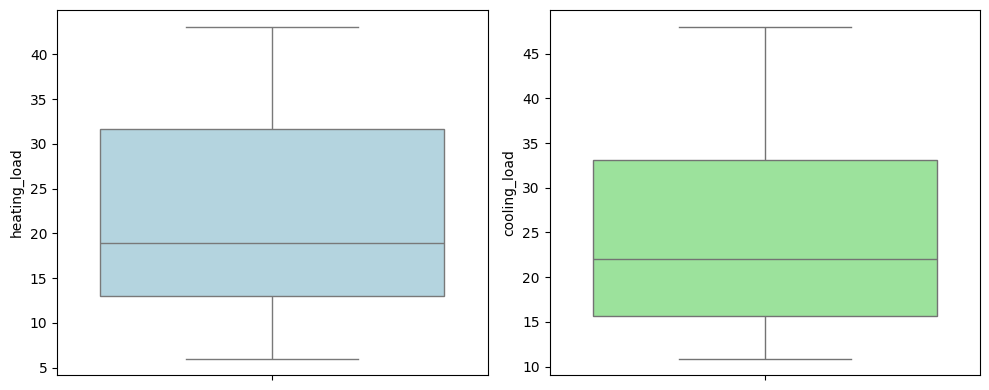

In [13]:
# outlier check with boxplots
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(y=df['heating_load'], ax=axes[0], color='lightblue')
sns.boxplot(y=df['cooling_load'], ax=axes[1], color='lightgreen')
plt.tight_layout()
plt.show()

**Observations**
- Taller buildings (7 m) and bigger glazing area have higher loads.
- Higher relative compactness is linked with a different pattern for heating and cooling, so the relationship is not purely a straight line.
- The loads have two clusters (low and high), which comes from the two building heights.
- There are no extreme outliers, so no rows will be removed.

## 4. Train / Test split

The test set is kept aside and only used to judge the models. All tuning is done on the training set.

In [14]:
from sklearn.model_selection import train_test_split

X = df[df.columns.drop(['heating_load', 'cooling_load'])]
y = df[['heating_load', 'cooling_load']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


## 5. Model 1 - Linear Regression

A small helper function is used so the same metrics are printed for every model.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(y_true, y_pred, title=''):
    # prints MAE, MSE, RMSE and R2 for each target
    print(f'------ {title} ------')
    for i, target in enumerate(y_true.columns):
        mae = mean_absolute_error(y_true[target], y_pred[:, i])
        mse = mean_squared_error(y_true[target], y_pred[:, i])
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true[target], y_pred[:, i])
        print(f'\n{target}\nMAE : {mae:.3f}\nMSE : {mse:.3f}\nRMSE : {rmse:.3f}\nR2 : {r2:.3f}')
    print()


def train_vs_test_r2(model, X_tr, y_tr, X_te, y_te):
    # compares train and test R2 to check for overfitting
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    for i, target in enumerate(y_tr.columns):
        print(target,
              'Train R2:', round(r2_score(y_tr[target], train_pred[:, i]), 3),
              '| Test R2:', round(r2_score(y_te[target], test_pred[:, i]), 3))

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lr_pred = lin_reg.predict(X_test)

coef = pd.DataFrame(lin_reg.coef_.T, index=X_test.columns, columns=y_test.columns)
print(coef)
print(f'intercept : {lin_reg.intercept_}')

evaluate_model(y_test, lr_pred, 'Linear Regression - TEST')

                           heating_load  cooling_load
relative_compactness         -61.873354    -71.084528
surface_area                  -0.060105     -0.069220
wall_area                      0.037553      0.025423
roof_area                     -0.048829     -0.047322
overall_height                 4.123669      4.046160
orientation                   -0.032439      0.055210
glazing_area                  20.143192     14.787587
glazing_area_distribution      0.211103      0.033740
intercept : [ 79.72697958 100.59454263]
------ Linear Regression - TEST ------

heating_load
MAE : 2.182
MSE : 9.153
RMSE : 3.025
R2 : 0.912

cooling_load
MAE : 2.195
MSE : 9.893
RMSE : 3.145
R2 : 0.893



In [17]:
print('---- TRAIN vs TEST R2 (Linear Regression) ----')
train_vs_test_r2(lin_reg, X_train, y_train, X_test, y_test)

---- TRAIN vs TEST R2 (Linear Regression) ----
heating_load Train R2: 0.917 | Test R2: 0.912
cooling_load Train R2: 0.886 | Test R2: 0.893


**Observation:** Linear Regression gets R2 of about 0.90 on both targets and the train and test scores are close,
so the model is **not overfitting** - it is simply too simple (underfitting) to capture the curved relationships.

## 6. Model 2 - Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
rf_pred = rf_reg.predict(X_test)

evaluate_model(y_test, rf_pred, 'Random Forest - TEST')

print('---- TRAIN vs TEST R2 (Random Forest) ----')
train_vs_test_r2(rf_reg, X_train, y_train, X_test, y_test)

------ Random Forest - TEST ------

heating_load
MAE : 0.347
MSE : 0.247
RMSE : 0.497
R2 : 0.998

cooling_load
MAE : 1.166
MSE : 3.635
RMSE : 1.906
R2 : 0.961

---- TRAIN vs TEST R2 (Random Forest) ----
heating_load Train R2: 1.0 | Test R2: 0.998
cooling_load Train R2: 0.995 | Test R2: 0.961


**Observation:** Random Forest is much better (R2 about 0.998 for heating and 0.96 for cooling).
Train R2 is higher than test R2 for cooling, which is a small sign of overfitting, but the test score is still very high.

## 7. Feature importance

relative_compactness         0.469
overall_height               0.199
surface_area                 0.143
roof_area                    0.066
glazing_area                 0.065
wall_area                    0.037
glazing_area_distribution    0.014
orientation                  0.006
dtype: float64


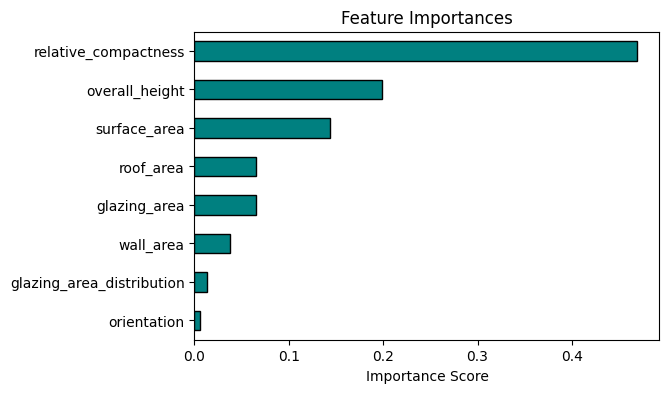

In [19]:
importances = pd.Series(rf_reg.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.round(3))

plt.figure(figsize=(6,4))
importances.plot(kind='barh', color='teal', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()

**Observation:** `relative_compactness` and `overall_height` are the most important features (together about 65%).
`orientation` and `glazing_area_distribution` add almost nothing.

## 8. Actual vs Predicted and residuals

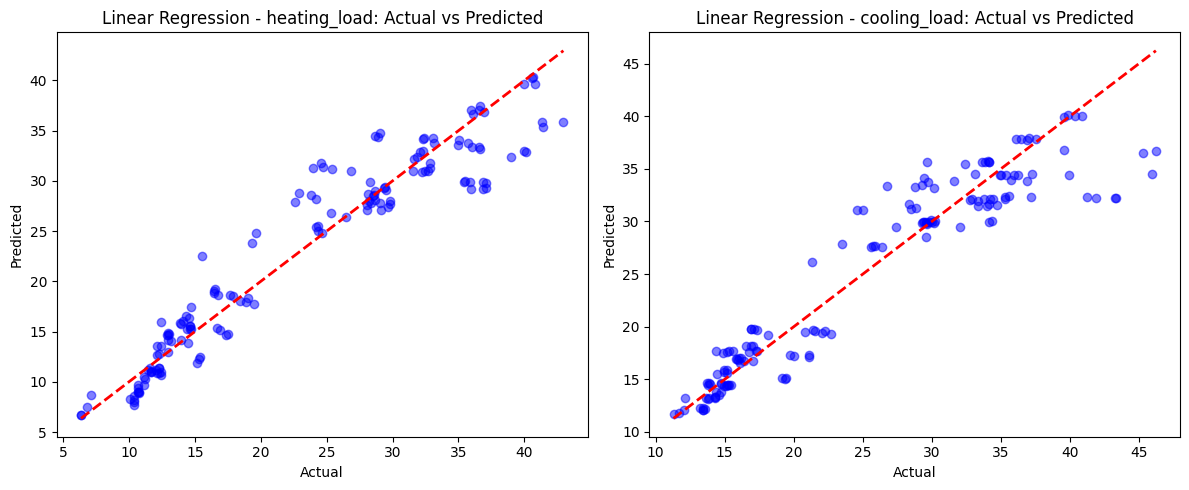

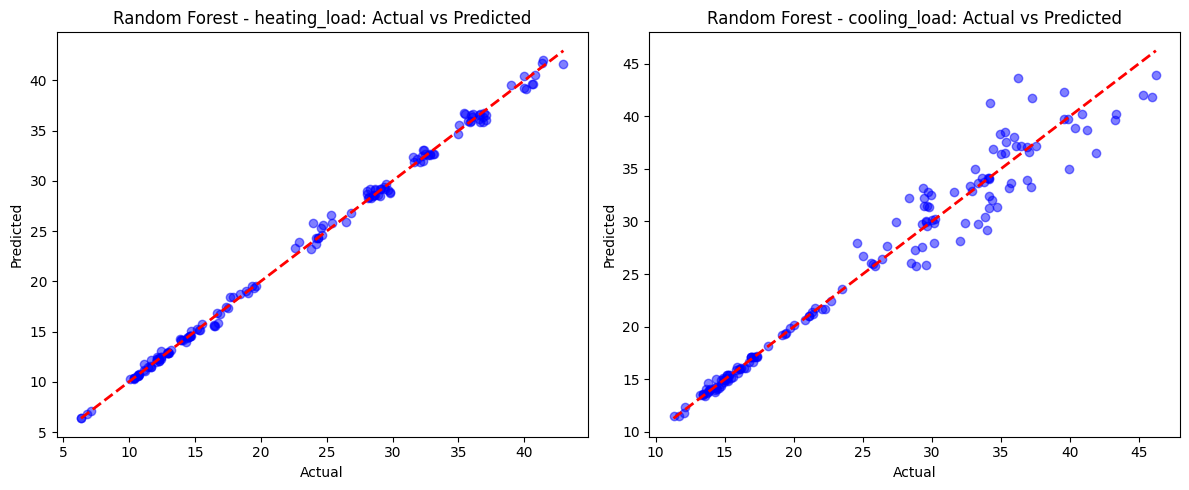

In [20]:
models_to_plot = {'Linear Regression': lr_pred, 'Random Forest': rf_pred}

for model_name, pred in models_to_plot.items():
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    for i, target in enumerate(y_test.columns):
        axes[i].scatter(y_test[target], pred[:, i], alpha=0.5, color='blue')
        axes[i].plot([y_test[target].min(), y_test[target].max()],
                     [y_test[target].min(), y_test[target].max()],
                     'r--', linewidth=2)
        axes[i].set_xlabel('Actual')
        axes[i].set_ylabel('Predicted')
        axes[i].set_title(f'{model_name} - {target}: Actual vs Predicted')

    plt.tight_layout()
    plt.show()

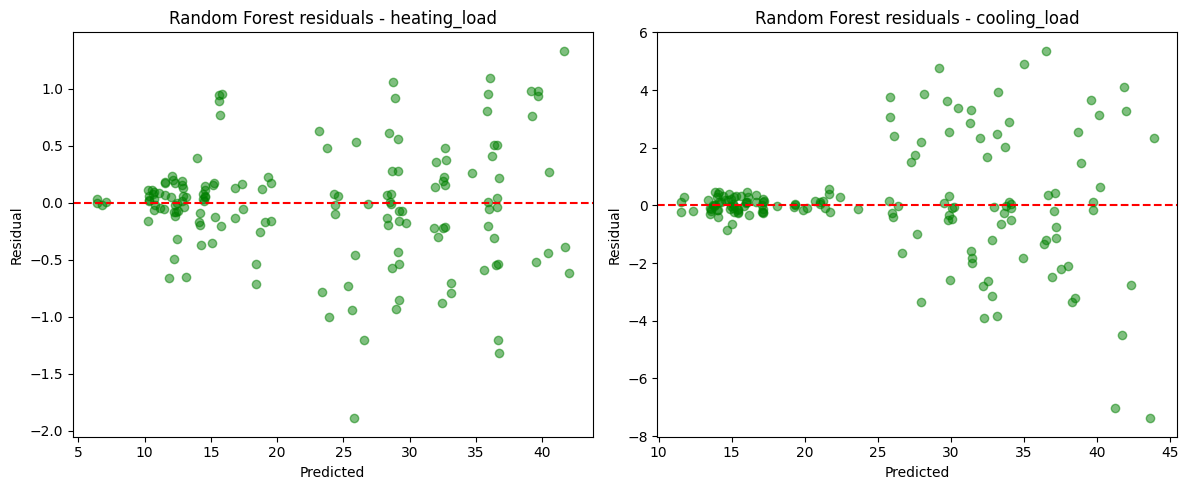

In [21]:
# residual = actual - predicted. Good models have residuals centred around 0 with no pattern
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for i, target in enumerate(y_test.columns):
    residuals = y_test[target] - rf_pred[:, i]
    axes[i].scatter(rf_pred[:, i], residuals, alpha=0.5, color='green')
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual')
    axes[i].set_title(f'Random Forest residuals - {target}')

plt.tight_layout()
plt.show()

**Observation:** Random Forest points sit very close to the red line. Linear Regression shows a curved pattern,
which confirms it is missing some non-linear behaviour.

## 9. Cross-validation

A single train/test split can be lucky or unlucky. 5-fold cross-validation on the training set gives a more reliable score.

In [22]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_score = cross_val_score(lin_reg, X_train, y_train, cv=kf, scoring='r2')
print('Linear Regression R2 Scores : ', lr_cv_score)
print('Mean R2: ', lr_cv_score.mean())
print('Standard Deviation R2 : ', lr_cv_score.std())

Linear Regression R2 Scores :  [0.9116789  0.89399289 0.8848615  0.90845255 0.89479032]
Mean R2:  0.8987552325921033
Standard Deviation R2 :  0.009924669359878522


In [23]:
rf_cv_score = cross_val_score(rf_reg, X_train, y_train, cv=kf, scoring='r2')
print('Random Forest R2 Scores : ', rf_cv_score)
print('Mean R2: ', rf_cv_score.mean())
print('Standard Deviation R2 : ', rf_cv_score.std())

Random Forest R2 Scores :  [0.975328   0.9811409  0.975874   0.97526782 0.98110721]
Mean R2:  0.9777435827330736
Standard Deviation R2 :  0.0027682311503142783


In [24]:
# Cross-validation for each target separately
for target in y_train.columns:
    rf_target_cv = cross_val_score(rf_reg, X_train, y_train[target], cv=kf, scoring='r2')
    print(f'Random Forest - {target}')
    print('R2 Scores:', rf_target_cv)
    print('Mean R2:', rf_target_cv.mean())
    print('Standard Deviation R2:', rf_target_cv.std())
    print()

Random Forest - heating_load
R2 Scores: [0.99748119 0.99774416 0.99744715 0.99695117 0.99693038]
Mean R2: 0.997310809142166
Standard Deviation R2: 0.00031921233920220396



Random Forest - cooling_load
R2 Scores: [0.95850932 0.97243875 0.96717806 0.96344627 0.97170994]
Mean R2: 0.9666564687668882
Standard Deviation R2: 0.005213940727764135



**Observation:** The CV scores match the test scores and the standard deviation is very small,
so the results are stable and not a lucky split. Cooling load is harder to predict than heating load.

## 10. Feature selection experiment

`orientation` and `glazing_area_distribution` have very low importance. Do we lose anything if we remove them?

*(In the original version this cell built a new X and y but the CV still used the old 8-feature training data, so the results were identical. Here the data is split again with 6 features so the comparison is fair.)*

In [25]:
X_small = X.drop(columns=['orientation', 'glazing_area_distribution'])

# same random_state so the same rows go to train and test
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_small, y, test_size=0.2, random_state=42)
print(X_train_s.shape, X_test_s.shape)

rf_small = RandomForestRegressor(n_estimators=100, random_state=42)

for target in y_train_s.columns:
    scores_8 = cross_val_score(rf_reg, X_train, y_train[target], cv=kf, scoring='r2')
    scores_6 = cross_val_score(rf_small, X_train_s, y_train_s[target], cv=kf, scoring='r2')
    print(f'\n{target}')
    print(f'8 features -> Mean R2: {scores_8.mean():.4f} (std {scores_8.std():.4f})')
    print(f'6 features -> Mean R2: {scores_6.mean():.4f} (std {scores_6.std():.4f})')

(614, 6) (154, 6)



heating_load
8 features -> Mean R2: 0.9973 (std 0.0003)
6 features -> Mean R2: 0.9976 (std 0.0002)



cooling_load
8 features -> Mean R2: 0.9667 (std 0.0052)
6 features -> Mean R2: 0.9680 (std 0.0026)


**Observation:** The 6-feature model scores the same as (or slightly better than) the 8-feature model, so those two features are not needed for prediction.
We keep all 8 features for the rest of the project to stay consistent, but a simpler 6-feature model would be just as good.

## 11. Ridge and Lasso (with scaling)

Linear models need **scaled** features before coefficients can be compared.
A `Pipeline` is used so the scaler is fitted only on the training part of each fold (this avoids data leakage).

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1)
}

results = []
for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    results.append({
        'Model': name,
        'Mean R2': round(scores.mean(), 4),
        'Std R2': round(scores.std(), 4)
    })

cv_results = pd.DataFrame(results)
print(cv_results)

               Model  Mean R2  Std R2
0  Linear Regression   0.8988  0.0099
1  Ridge (alpha=1.0)   0.8986  0.0098
2  Lasso (alpha=0.1)   0.8934  0.0105


In [27]:
# Fit the three pipelines and keep their scaled coefficients
coef_tables = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    coef_tables[name] = pd.DataFrame(
        pipe.named_steps['model'].coef_.T,
        index=X_train.columns,
        columns=y_train.columns
    )

for target in y_train.columns:
    comparison = pd.concat(
        [coef_tables['Linear Regression'][target],
         coef_tables['Ridge (alpha=1.0)'][target],
         coef_tables['Lasso (alpha=0.1)'][target]],
        axis=1, keys=['Linear', 'Ridge', 'Lasso']
    )
    print(f'\n{target}')
    print(comparison.round(2))


heating_load
                           Linear  Ridge  Lasso
relative_compactness        -6.52  -5.38  -0.00
surface_area                -3.60  -2.85   0.00
wall_area                    0.80   0.99   2.16
roof_area                   -3.92  -3.27  -0.00
overall_height               7.22   7.48   8.25
orientation                 -0.04  -0.04  -0.00
glazing_area                 2.70   2.70   2.64
glazing_area_distribution    0.33   0.33   0.25

cooling_load
                           Linear  Ridge  Lasso
relative_compactness        -7.49  -6.14  -0.45
surface_area                -4.14  -3.23   0.00
wall_area                    0.14   0.36   1.50
roof_area                   -4.12  -3.35  -0.00
overall_height               7.08   7.42   8.34
orientation                  0.06   0.06   0.00
glazing_area                 1.98   1.98   1.92
glazing_area_distribution    0.05   0.05   0.00


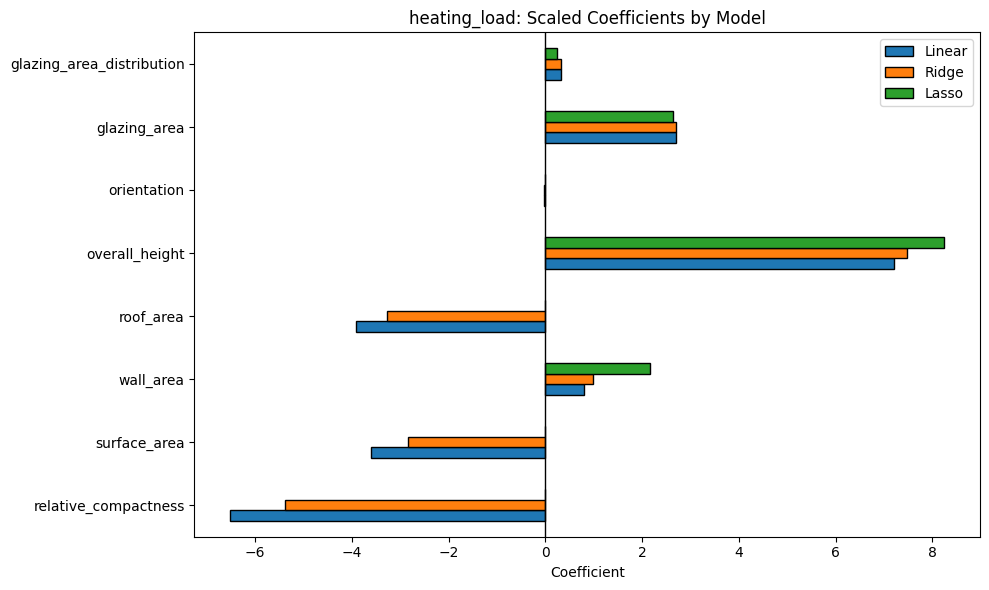

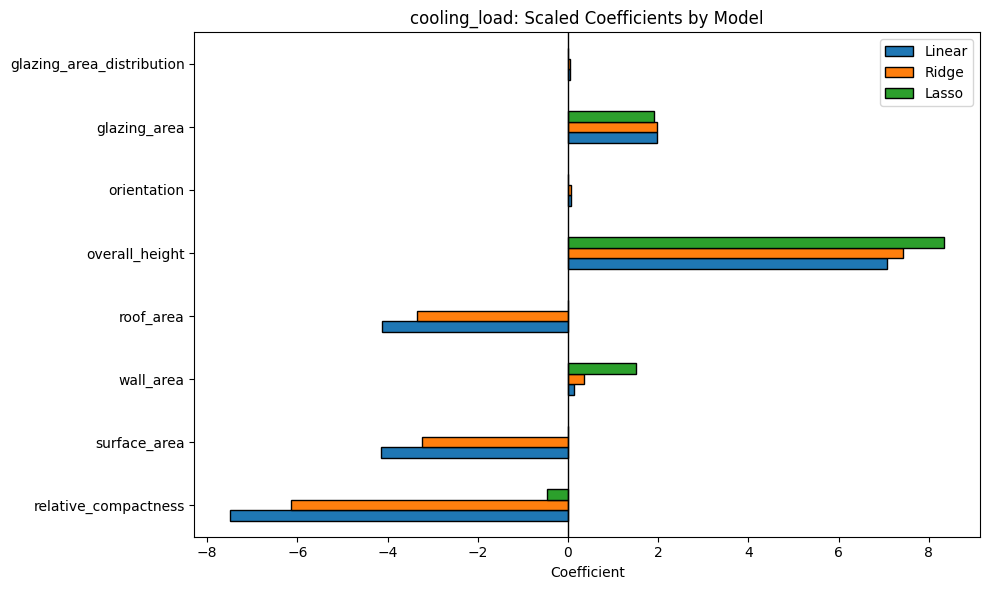

In [28]:
for target in y_train.columns:
    comparison = pd.concat(
        [coef_tables['Linear Regression'][target],
         coef_tables['Ridge (alpha=1.0)'][target],
         coef_tables['Lasso (alpha=0.1)'][target]],
        axis=1, keys=['Linear', 'Ridge', 'Lasso']
    )
    comparison.plot(kind='barh', figsize=(10,6), edgecolor='black')
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f'{target}: Scaled Coefficients by Model')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()

**Observations**
- Scaling does not change the predictions of Linear Regression, only the size of the coefficients (now comparable).
- Ridge shrinks the coefficients of the correlated features (`relative_compactness`, `surface_area`, `roof_area`) but the score stays the same.
- Lasso sets several coefficients to exactly 0 and keeps `overall_height`, `glazing_area` and `wall_area`. Its score drops a little, which shows
  that the correlated features still carry useful information when combined.
- Regularization does not help here: the problem is not overfitting, it is that a straight line is too simple.

## 12. Gradient Boosting and hyperparameter tuning

Two more steps:
1. Try a Gradient Boosting model (it predicts one target at a time, so `MultiOutputRegressor` is used).
2. Tune the Random Forest with `GridSearchCV` instead of using the default settings.

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

gb_reg = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, random_state=42))
gb_reg.fit(X_train, y_train)
gb_pred = gb_reg.predict(X_test)

evaluate_model(y_test, gb_pred, 'Gradient Boosting - TEST')

print('---- TRAIN vs TEST R2 (Gradient Boosting) ----')
train_vs_test_r2(gb_reg, X_train, y_train, X_test, y_test)

------ Gradient Boosting - TEST ------

heating_load
MAE : 0.335
MSE : 0.199
RMSE : 0.446
R2 : 0.998

cooling_load
MAE : 0.896
MSE : 1.632
RMSE : 1.277
R2 : 0.982

---- TRAIN vs TEST R2 (Gradient Boosting) ----
heating_load Train R2: 0.999 | Test R2: 0.998
cooling_load Train R2: 0.988 | Test R2: 0.982


In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best parameters :', grid.best_params_)
print('Best CV R2 :', round(grid.best_score_, 4))

Best parameters : {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 300}
Best CV R2 : 0.9791


In [31]:
best_rf = grid.best_estimator_
best_rf_pred = best_rf.predict(X_test)

evaluate_model(y_test, best_rf_pred, 'Tuned Random Forest - TEST')

print('---- TRAIN vs TEST R2 (Tuned Random Forest) ----')
train_vs_test_r2(best_rf, X_train, y_train, X_test, y_test)

------ Tuned Random Forest - TEST ------

heating_load
MAE : 0.415
MSE : 0.422
RMSE : 0.649
R2 : 0.996

cooling_load
MAE : 1.236
MSE : 3.674
RMSE : 1.917
R2 : 0.960

---- TRAIN vs TEST R2 (Tuned Random Forest) ----
heating_load Train R2: 0.997 | Test R2: 0.996
cooling_load Train R2: 0.974 | Test R2: 0.96


## 13. Final comparison on the test set

All models are compared on the same unseen test data.

In [32]:
all_predictions = {
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred,
    'Tuned Random Forest': best_rf_pred
}

final_rows = []
for model_name, pred in all_predictions.items():
    for i, target in enumerate(y_test.columns):
        final_rows.append({
            'Model': model_name,
            'Target': target,
            'MAE': round(mean_absolute_error(y_test[target], pred[:, i]), 3),
            'RMSE': round(np.sqrt(mean_squared_error(y_test[target], pred[:, i])), 3),
            'R2': round(r2_score(y_test[target], pred[:, i]), 4)
        })

final_results = pd.DataFrame(final_rows)
print(final_results)

                 Model        Target    MAE   RMSE      R2
0    Linear Regression  heating_load  2.182  3.025  0.9122
1    Linear Regression  cooling_load  2.195  3.145  0.8932
2        Random Forest  heating_load  0.347  0.497  0.9976
3        Random Forest  cooling_load  1.166  1.906  0.9608
4    Gradient Boosting  heating_load  0.335  0.446  0.9981
5    Gradient Boosting  cooling_load  0.896  1.277  0.9824
6  Tuned Random Forest  heating_load  0.415  0.649  0.9960
7  Tuned Random Forest  cooling_load  1.236  1.917  0.9603


**Observation:** Gradient Boosting is the best model, mainly because it predicts cooling load better
(R2 0.982 and RMSE 1.28, compared with 0.961 and 1.91 for Random Forest).
Tuning the Random Forest improved its cross-validation score, but not its test score, so the default settings were already good enough.

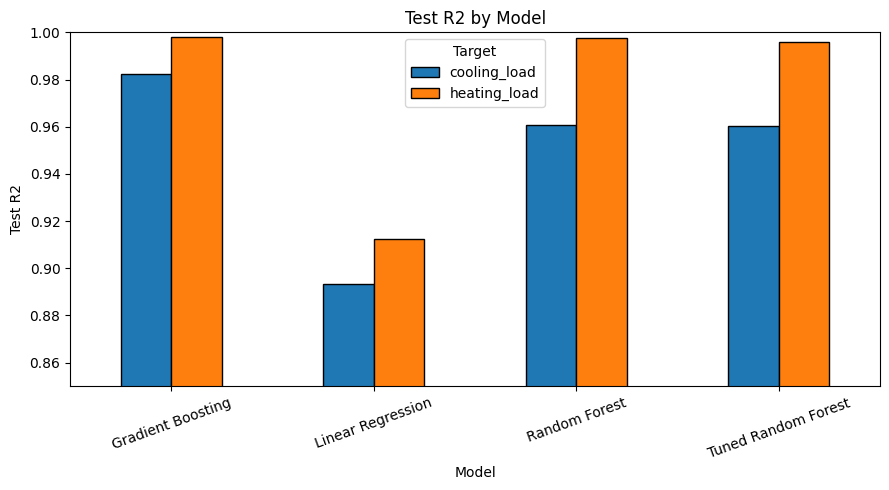

In [33]:
# bar chart of test R2 for each model
r2_table = final_results.pivot(index='Model', columns='Target', values='R2')
r2_table.plot(kind='bar', figsize=(9,5), edgecolor='black')
plt.ylim(0.85, 1.0)
plt.ylabel('Test R2')
plt.title('Test R2 by Model')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 14. Save the model and predict for a new building

In [34]:
import joblib

# Gradient Boosting had the best test scores in the table above
final_model = gb_reg
joblib.dump(final_model, 'energy_model.pkl')

# example: a new building with the same 8 features
new_building = pd.DataFrame([{
    'relative_compactness': 0.90,
    'surface_area': 563.5,
    'wall_area': 318.5,
    'roof_area': 122.5,
    'overall_height': 7.0,
    'orientation': 3,
    'glazing_area': 0.25,
    'glazing_area_distribution': 2
}])

loaded_model = joblib.load('energy_model.pkl')
prediction = loaded_model.predict(new_building)
print(f'Predicted heating load : {prediction[0][0]:.2f}')
print(f'Predicted cooling load : {prediction[0][1]:.2f}')

Predicted heating load : 32.73
Predicted cooling load : 33.53


## 15. Conclusions

**Results**
- Linear, Ridge and Lasso regression reach R2 of about 0.90. They are too simple for this data because the relationships are non-linear.
- Random Forest and Gradient Boosting reach R2 of about 0.998 for heating load. For cooling load, Random Forest gets 0.96 and Gradient Boosting gets 0.98.
- **Gradient Boosting is the best final model** (test RMSE 0.45 for heating and 1.28 for cooling). Tuning the Random Forest did not beat it.
- Cooling load is harder to predict than heating load for every model.
- Cross-validation scores match the test scores with a small standard deviation, so the results are stable.

**Key drivers of energy load**
- `relative_compactness` and `overall_height` are the most important features.
- `orientation` and `glazing_area_distribution` have almost no effect and can be removed without losing accuracy.

**Practical meaning:** At the design stage, a building's compactness and height matter far more than its orientation. More compact, lower buildings need less energy.

**Limitations**
- The data is simulated and has only 768 rows (a small set of base shapes, each repeated with different orientation and glazing), so the same building shape can appear in both train and test. The scores are probably a little optimistic for completely new building shapes.
- Only one climate and one building type are covered.

**Possible next steps**
- Use `GroupKFold` so that all rows of the same building shape stay together in one fold.
- Try feature engineering (for example height x compactness) and other models such as XGBoost.
- Collect real-world data to test whether the model generalises.